In [1]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
RAW_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/raw"
IMAGES_DIR = os.path.join(RAW_DIR, "images")
CSV_PATH = os.path.join(RAW_DIR, "data_all.csv")

## SECTION A — CSV INSPECTION

In [3]:
df = pd.read_csv(CSV_PATH)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

Dataset Shape: (1764, 3)

Columns:
Index(['Unnamed: 0', 'file', 'cat'], dtype='object')

First 5 Rows:


,Unnamed: 0,file,cat
0,0,o_c1t10003118.jpg,1
1,1,o_c1t1003016260.jpg,1
2,2,o_c1t1004522299.jpg,1
3,3,o_c1t1008823172.jpg,1
4,4,o_c1t1011431188.jpg,1



Last 5 Rows:


,Unnamed: 0,file,cat
1759,1759,o_c3t992926103.jpg,3
1760,1760,o_c3t993929121.jpg,3
1761,1761,o_c3t994023728.jpg,3
1762,1762,o_c3t996710741.jpg,3
1763,1763,o_c3t999411633.jpg,3


In [4]:
df = df[['file', 'cat']]
print("Cleaned DataFrame Shape:", df.shape)

Cleaned DataFrame Shape: (1764, 2)


In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
file    0
cat     0
dtype: int64

Duplicate Rows: 0


## SECTION B — FILE INTEGRITY CHECK

**1. CHECK MISSING IMAGE FILES**

In [6]:
missing_files = []

for file_name in df['file']:
    file_path = os.path.join(IMAGES_DIR, file_name)
    if not os.path.exists(file_path):
        missing_files.append(file_name)

print("Missing Image Files:", len(missing_files))

if missing_files:
    print("\nSample Missing Files:")
    print(missing_files[:10])

Missing Image Files: 0


**2. CHECK CORRUPTED IMAGES**

In [7]:
corrupt_files = []

for file_name in df['file']:
    file_path = os.path.join(IMAGES_DIR, file_name)

    if os.path.exists(file_path):
        try:
            with Image.open(file_path) as img:
                img.verify()
        except:
            corrupt_files.append(file_name)

print("Corrupted Images:", len(corrupt_files))

if corrupt_files:
    print("\nSample Corrupt Files:")
    print(corrupt_files[:10])

Corrupted Images: 0


## SECTION C — CLASS DISTRIBUTION

In [5]:
class_counts = df['cat'].value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

Class Distribution:
cat
1    811
2    569
3    384
Name: count, dtype: int64


(array([0, 1, 2]), [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '3')])

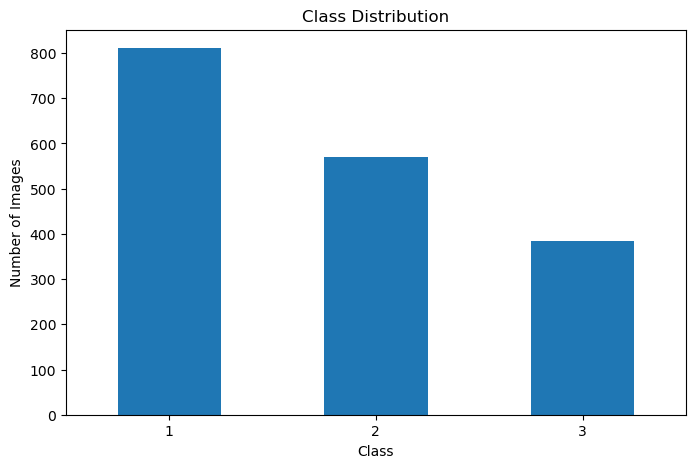

In [6]:
plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

- Total images: 1764
- Class imbalance: Moderate
- Majority class: Class 1 (45.98%)
- Minority class: Class 3 (21.77%)
- Recommended action:
  1. Stratified split
  2. Class weights during training
  3. Monitor per-class recall/F1

## IMAGE RESOLUTION ANALYSIS

**1. IMAGE SIZE ANALYSIS**

In [7]:
image_sizes = []

for file_name in df['file']:
    file_path = os.path.join(IMAGES_DIR, file_name)

    if os.path.exists(file_path):
        try:
            with Image.open(file_path) as img:
                image_sizes.append(img.size)  # (width, height)
        except:
            continue

print("Total Valid Images Checked:", len(image_sizes))

Total Valid Images Checked: 1764


**2. MOST COMMON RESOLUTIONS**

In [8]:
resolution_counts = Counter(image_sizes)

print("Top 10 Most Common Image Resolutions:")
for resolution, count in resolution_counts.most_common(10):
    print(f"{resolution}: {count}")

Top 10 Most Common Image Resolutions:
(899, 900): 278
(899, 680): 259
(898, 900): 164
(834, 674): 39
(767, 597): 36
(765, 597): 34
(763, 597): 31
(846, 646): 30
(845, 646): 28
(766, 597): 28


**3. RESOLUTION SCATTER PLOT**

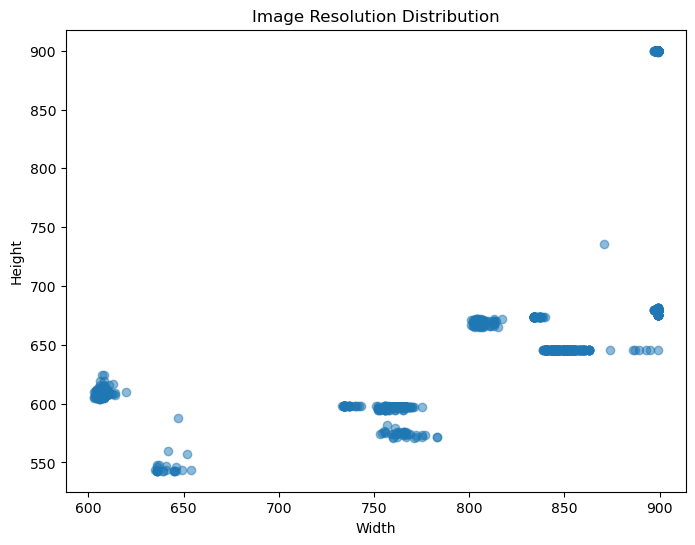

In [9]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

plt.figure(figsize=(8,6))
plt.scatter(widths, heights, alpha=0.5)
plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

## SECTION E — VISUAL SAMPLES

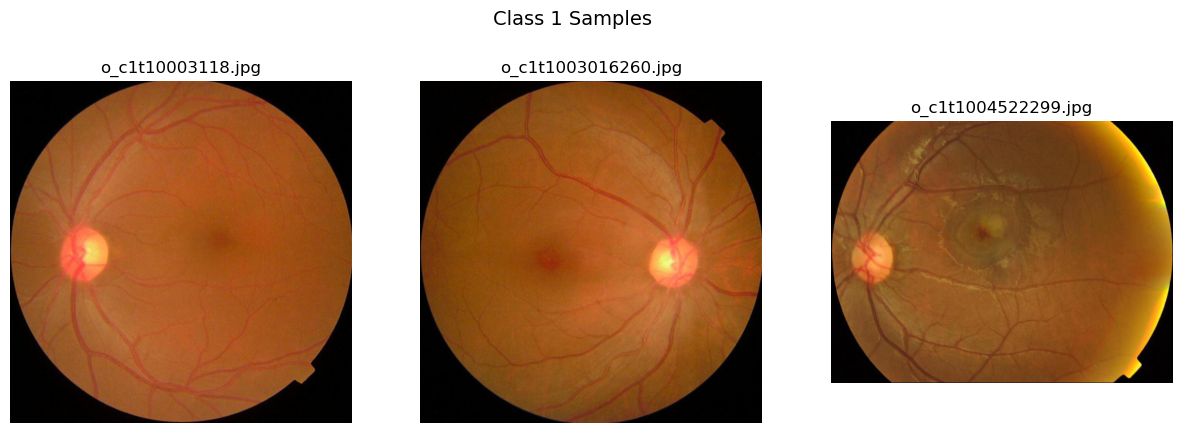

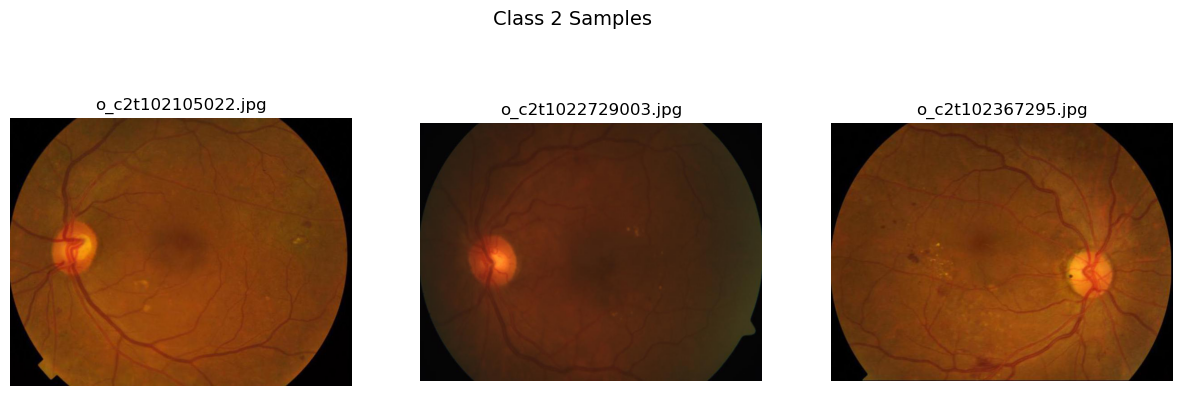

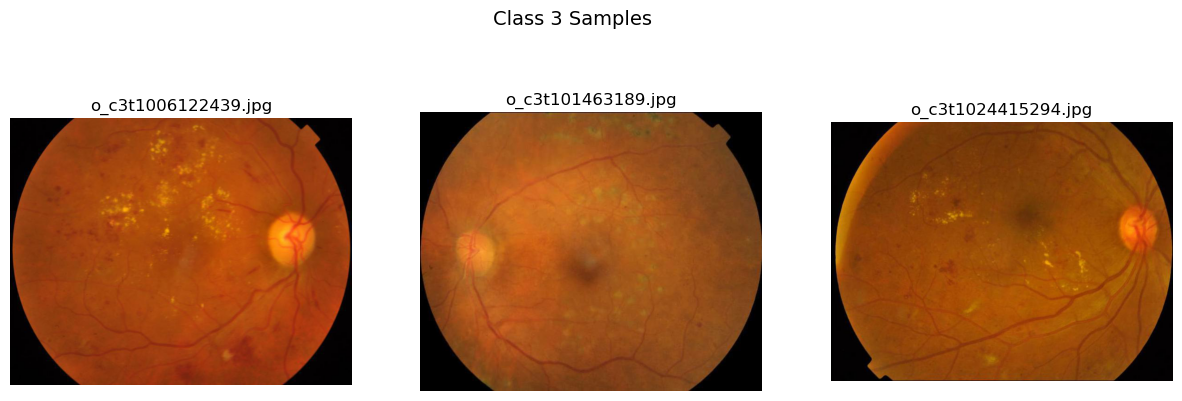

In [10]:
samples_per_class = 3

for class_label in sorted(df['cat'].unique()):
    class_files = df[df['cat'] == class_label]['file'].head(samples_per_class)

    plt.figure(figsize=(15,5))
    plt.suptitle(f"Class {class_label} Samples", fontsize=14)

    for i, file_name in enumerate(class_files, start=1):
        file_path = os.path.join(IMAGES_DIR, file_name)

        if os.path.exists(file_path):
            try:
                img = Image.open(file_path)

                plt.subplot(1, samples_per_class, i)
                plt.imshow(img)
                plt.title(file_name)
                plt.axis("off")

            except:
                continue

    plt.show()